# Credit Card Fraud Detection

This notebook focuses on predicting fraudulent credit card transactions. The dataset is highly imbalanced, so we will use specialized techniques such as hyperparameter tuning for Average Precision, and utilizing class weights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

## 1. Data Loading
We load the `creditcard` dataset from OpenML (ID 1597). This dataset contains 284,807 transactions, where only 492 are frauds (0.17%).

In [2]:
print("Fetching dataset...")
fraud_data = fetch_openml(data_id=1597, as_frame=True, parser='auto')
df = fraud_data.frame

# Ensure target is an integer (0 or 1)
df['Class'] = df['Class'].astype(int)

df.head()

Fetching dataset...


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis

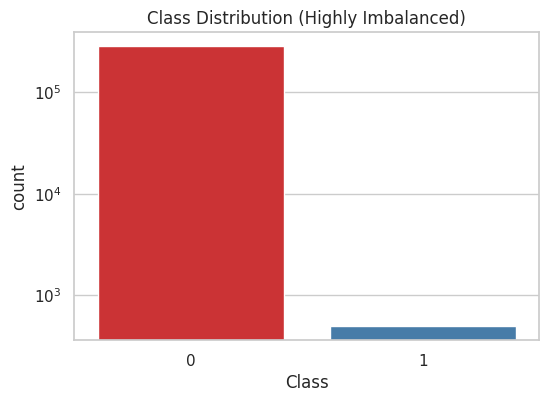

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df, 
    x='Class', 
    hue='Class',      
    palette='Set1', 
    legend=False   
)

plt.title("Class Distribution (Highly Imbalanced)")
plt.yscale('log')    
plt.show()

print("Class distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage: {:.3f}%".format(df['Class'].value_counts()[1] / len(df) * 100))

## 3. Data Preprocessing
The V1-V28 features are already PCA transformed, so they are scaled. We just need to scale `Amount`.

In [9]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
# Only fit the scaler on train data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale Amount
X_train_scaled[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled[['Amount']] = scaler.transform(X_test[['Amount']])

## 4. Fine-Tuning the Model
We use `RandomizedSearchCV` to find the best hyperparameters for our Random Forest model. Because the dataset is massive, we use a smaller number of iterations and trees to keep training time reasonable.

In [ ]:
# Base model with class_weight='balanced' to handle the imbalance
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Hyperparameter grid
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Setup RandomizedSearchCV optimizing for Average Precision (AUPRC)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3, # Kept small for demonstration speed
    scoring='average_precision',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

Starting hyperparameter tuning...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


## 5. Model Evaluation
With highly imbalanced data, accuracy is misleading (a model predicting 0 always would be 99.8% accurate). We use Precision, Recall, and the Precision-Recall Curve.

In [ ]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

auprc = average_precision_score(y_test, y_prob)
print(f"\nAverage Precision Score (AUPRC): {auprc:.4f}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title("Confusion Matrix")
ax[0].grid(False)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ax[1].plot(recall, precision, marker='.', color='darkorange')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title(f'Precision-Recall Curve (AUPRC={auprc:.3f})')

plt.tight_layout()
plt.show()